# (A) Project Scope

The dataset used in this project is PokerBench from HuggingFace. It contains approximately **500,000 post-flop poker hands**, where each entry represents a decision point with structured information such as betting sequences, pot size, board cards, and player position. The dataset also includes **a GTO-approved correct decision** for the player (“hero”), which serves as the target variable. The data consists of categorical tokens, sequential action text, and numeric features, making it suitable for multiple data mining techniques including decision trees, text embeddings, and frequent itemset analysis.

Initial exploratory analysis focused on feature distributions and their relationship with the correct decision. The data shows a strong skew toward **passive actions (check, call, fold)**, which account for roughly 75% of optimal decisions, while aggressive actions such as betting or raising occur less frequently. Several contextual features appear related to these decisions, including **player position, pot size, and evaluation street**. For example, out-of-position players tend to take more passive actions, while larger pots more frequently result in folds. These patterns suggest that variables such as position and pot size may produce informative splits when constructing a decision tree.

The analysis also revealed **imbalances in the distribution of evaluation street and player position**, raising the possibility of selection bias in the dataset. Since the scenarios were curated by professional poker players for benchmarking purposes, the data may emphasize certain strategic situations over others. This motivates further analysis using statistical methods and pattern mining techniques to better understand the structure and potential biases within the dataset.




Dataset Size / Structure: 500,000 hands, each hand contains text-encoded sequential play information, pot size, and GTO-approved play

Data Types: Categorical sequences, tokens, numerics, categorical labels

Course Topic: Decision Trees, Frequent Itemsets
- Decision trees to learn check / bet / raise / fold
- Frequent itemsets to check distribution of benchmark hands, potential bias or post-flop tendencies

Beyond Course Technique: Chi-Squared Tests
- Checking associations between correct decision and hero position

# (B) Research Question Definition

**RQ1: Which game-state variables most effectively predict the GTO-approved decision (check, call, bet, raise, fold)?**
- Data Mining Task Type: Classification
- Relevant Algorithm(s):
  - Decision Tree (course technique)
  - CART or ID3 implementations (external technique)
- Evaluation Criteria:
  - Accuracy / classification error
  - Tree depth (complexity)
  - Information gain / entropy reduction
  - Interpretability of splits




**RQ2: What common patterns of board texture and betting context occur in the PokerBench dataset, and do they reveal potential selection bias in benchmark hands?**
- Data Mining Task Type: Frequent Itemset Mining
- Relevant Algorithm(s):
  - Apriori (course technique)
- Evaluation Criteria:
  - Support
  - Confidence
  - Lift
  - Interpretability of discovered itemsets



**RQ3: Is there a statistically significant association between player position and the GTO-approved decision?**
- Data Mining Task Type: Statistical Association Analysis
- Relevant Algorithm(s):
  - Chi-Squared Test of Independence (external technique)
- Evaluation Criteria:
  - Chi-square statistic
  - p-value
  - Effect size (Cramér’s V)




<table border="1" style="border-collapse:collapse; width:100%; text-align:left;">
<thead>
<tr>
<th>RQ</th>
<th>Research Question</th>
<th>Data Mining Task</th>
<th>Algorithm / Method</th>
<th>Course or External</th>
<th>Evaluation Criteria</th>
</tr>
</thead>
<tbody>
<tr>
<td><b>RQ1</b></td>
<td>Which game-state variables most effectively predict the GTO-approved decision (check, call, bet, raise, fold)?</td>
<td>Classification</td>
<td>Decision Tree (CART / ID3)</td>
<td>Course</td>
<td>Accuracy, entropy / information gain, tree depth, interpretability</td>
</tr>
<tr>
<td><b>RQ2</b></td>
<td>What common patterns of board texture and betting context occur in the dataset, and do they reveal potential selection bias in benchmark hands?</td>
<td>Frequent Itemset Mining</td>
<td>Apriori</td>
<td>Course</td>
<td>Support, confidence, lift, interpretability of itemsets</td>
</tr>
<tr>
<td><b>RQ3</b></td>
<td>Is there a statistically significant association between player position and the GTO-approved decision?</td>
<td>Statistical Association Analysis</td>
<td>Chi-Squared Test of Independence</td>
<td>External</td>
<td>Chi-square statistic, p-value, effect size (Cramér’s V)</td>
</tr>
</tbody>
</table>


# (C) Motivation & Feasibility

In [2]:
# Loading

from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("postflop_500k_train_set_game_scenario_information.csv")

df.head()
df.info()

Saving postflop_500k_train_set_game_scenario_information.csv to postflop_500k_train_set_game_scenario_information.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Unnamed: 0          500000 non-null  int64 
 1   preflop_action      500000 non-null  object
 2   board_flop          500000 non-null  object
 3   board_turn          500000 non-null  object
 4   board_river         500000 non-null  object
 5   aggressor_position  500000 non-null  object
 6   postflop_action     500000 non-null  object
 7   evaluation_at       500000 non-null  object
 8   available_moves     500000 non-null  object
 9   pot_size            500000 non-null  int64 
 10  hero_position       500000 non-null  object
 11  holding             500000 non-null  object
 12  correct_decision    500000 non-null  object
dtypes: int64(2), object(11)
memory 

In [3]:
# Basic Cleaning
df = df.rename(columns={"Unnamed: 0": "Index"})

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Convert pot size to numeric (just in case)
df["pot_size"] = pd.to_numeric(df["pot_size"], errors="coerce")

# Make sure categorical columns are strings
cat_cols = [
    "preflop_action", "board_flop", "board_turn", "board_river",
    "aggressor_position", "postflop_action", "evaluation_at",
    "hero_position", "holding", "correct_decision"
]

for col in cat_cols:
    df[col] = df[col].astype(str)

df.head()

,Index,preflop_action,board_flop,board_turn,board_river,aggressor_position,postflop_action,evaluation_at,available_moves,pot_size,hero_position,holding,correct_decision
0,0,HJ/2.0bb/BB/call,JcJh4s,4d,As,OOP,OOP_CHECK/IP_BET_1/OOP_CALL/dealcards/4d/OOP_C...,River,"['Check', 'Bet 17']",21,IP,AhKd,Check
1,1,SB/3.0bb/BB/call,6s8d7c,9s,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/9s/OOP_BET_5/IP_R...,Turn,"['Fold', 'Call', 'Raise 41']",27,OOP,Tc9c,Call
2,2,UTG/2.0bb/CO/6.5bb/UTG/call,JcJh4s,4d,As,IP,OOP_CHECK/IP_BET_7/OOP_RAISE_16/IP_CALL/dealca...,Turn,"['Fold', 'Call']",151,IP,QsQh,Call
3,3,UTG/2.0bb/BTN/call,Th3s2d,5d,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/5d/OOP_BET_6/IP_C...,River,"['Check', 'Bet 13']",17,IP,JcTc,Check
4,4,CO/2.3bb/BB/call,Ks7h2d,Jc,Qc,OOP,OOP_CHECK/IP_CHECK/dealcards/Jc/OOP_CHECK/IP_B...,River,"['Check', 'Bet 29']",39,IP,Ac5c,Bet 29


In [10]:
def simplify_action(action):
    action = action.lower()

    if "bet" in action or "raise" in action:
        return "Bet/Raise"
    elif "check" in action:
        return "Check"
    elif "call" in action:
        return "Call"
    elif "fold" in action:
        return "Fold"
    else:
        return "Other"

df["decision_category"] = df["correct_decision"].apply(simplify_action)

df["decision_category"].value_counts()


,count
decision_category,
Check,125000
Call,125000
Bet/Raise,125000
Fold,125000


I chose to simplify the correct decision into 4 basic categories to increase the feasibility of my algorithms. Since the nuance to betting / raising is important, this could make for excellent follow-up research.

In [12]:
# RQ1 Feasibility EDA for Decision Trees

print("Target Variable Distribution:")
print(df["decision_category"].value_counts())
print("\nNormalized Distribution:")
print(df["decision_category"].value_counts(normalize=True))

print("\nHero Position Distribution:")
print(df["hero_position"].value_counts())

print("\nEvaluation Street Distribution:")
print(df["evaluation_at"].value_counts())

print("\nPot Size Summary Statistics:")
print(df["pot_size"].describe())

print("\nCategorical Feature Cardinality:")
for col in ["hero_position", "evaluation_at", "aggressor_position"]:
    print(f"{col}: {df[col].nunique()} unique values")


Target Variable Distribution:
decision_category
Check        125000
Call         125000
Bet/Raise    125000
Fold         125000
Name: count, dtype: int64

Normalized Distribution:
decision_category
Check        0.25
Call         0.25
Bet/Raise    0.25
Fold         0.25
Name: proportion, dtype: float64

Hero Position Distribution:
hero_position
IP     320184
OOP    179816
Name: count, dtype: int64

Evaluation Street Distribution:
evaluation_at
River    260419
Turn     207153
Flop      32428
Name: count, dtype: int64

Pot Size Summary Statistics:
count    500000.00000
mean         47.53266
std          41.34504
min           4.00000
25%          17.00000
50%          33.00000
75%          61.00000
max         176.00000
Name: pot_size, dtype: float64

Categorical Feature Cardinality:
hero_position: 2 unique values
evaluation_at: 3 unique values
aggressor_position: 2 unique values


**RQ1: Which game-state variables most effectively predict the GTO-approved decision (check, call, bet, raise, fold)?**

Motivation:
EDA suggested that position, pot size, and evaluation street may strongly influence decisions, while features such as flop texture or pocket pairs appear less important. A decision tree can reveal which variables produce the most informative splits and whether a relatively simple strategy can approximate GTO play.

Non-Triviality:
Need to evaluate the decision tree with both the objective, mathematical metrics learned in class and subjective downstream usability of the decision tree.

Feasibility: The dataset contains structured categorical and numeric variables, making it well-suited for decision tree classification. The correct decisions are well balanced if you combine bets / raises of any amount into one singular category (which could use a separate decision tree to determine amount). The distributions for various categories aren't perfectly even, but it makes sense within context. The categorical feature cardinality is quite limited.

Risk: The model may overfit due to the large number of categorical combinations. Additionally, severe class imbalance (passive vs aggressive actions) could bias splits unless pruning or class balancing is applied.

In [13]:
# RQ2 Feasibility EDA for Frequent Itemsets

cols = ["hero_position", "evaluation_at", "decision_category", "aggressor_position"]

print("Unique Value Counts:")
for col in cols:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nExample Transaction-Like Rows:")
print(df[cols].head())

print("\nCategorical Summary Statistics:")
print(df[cols].describe(include="all"))

print("\nValue Counts for Each Column:")
for col in cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


Unique Value Counts:
hero_position: 2 unique values
evaluation_at: 3 unique values
decision_category: 4 unique values
aggressor_position: 2 unique values

Example Transaction-Like Rows:
  hero_position evaluation_at decision_category aggressor_position
0            IP         River             Check                OOP
1           OOP          Turn              Call                OOP
2            IP          Turn              Call                 IP
3            IP         River             Check                OOP
4            IP         River         Bet/Raise                OOP

Categorical Summary Statistics:
       hero_position evaluation_at decision_category aggressor_position
count         500000        500000            500000             500000
unique             2             3                 4                  2
top               IP         River             Check                OOP
freq          320184        260419            125000             437946

Value Counts for E

**RQ2: What common patterns of board texture and betting context occur in the PokerBench dataset, and do they reveal potential selection bias in benchmark hands?**

Motivation:
Frequent itemsets can identify recurring combinations of game features (e.g., position + pot size + street + action). If certain configurations appear disproportionately often, this could suggest selection bias in the benchmark dataset rather than natural gameplay distributions.

Non-Triviality:
Need to assess if selection bias exists or if imbalanced distributions reflect natural gameplay scenarios.

Feasibility: The dataset naturally contains transactional-style categorical features (position, street, board cards, actions), which can be converted into itemsets. The correct decisions are well balanced if you combine bets / raises of any amount into one singular category. The distributions for various categories aren't perfectly even, but it makes sense within context. The categorical feature cardinality is quite limited.

Risk: Apriori may become computationally expensive if too many tokens are included, particularly from text-heavy fields like postflop_action.

Contingency Table (Hero Position vs Correct Decision):
decision_category  Bet/Raise   Call   Check   Fold
hero_position                                     
IP                     86629  60290  125000  48265
OOP                    38371  64710       0  76735

Row-Normalized Distribution:
decision_category  Bet/Raise      Call     Check      Fold
hero_position                                             
IP                   0.27056  0.188298  0.390401  0.150741
OOP                  0.21339  0.359868  0.000000  0.426742

Minimum Cell Count (Chi-Square assumption check):
0


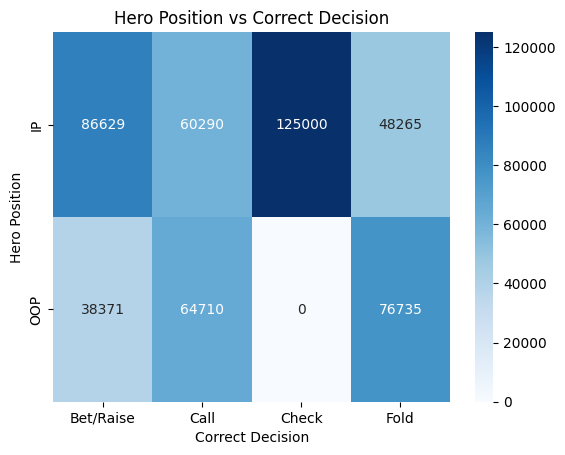

In [14]:
# RQ3 Feasibility EDA for Chi-Squared Test

import pandas as pd

print("Contingency Table (Hero Position vs Correct Decision):")
ct = pd.crosstab(df["hero_position"], df["decision_category"])
print(ct)

print("\nRow-Normalized Distribution:")
print(pd.crosstab(df["hero_position"], df["decision_category"], normalize="index"))

print("\nMinimum Cell Count (Chi-Square assumption check):")
print(ct.min().min())

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Hero Position vs Correct Decision")
plt.xlabel("Correct Decision")
plt.ylabel("Hero Position")
plt.show()


**RQ3: Is there a statistically significant association between player position and the GTO-approved decision?**

Motivation:
EDA suggested that out-of-position players fold or call more frequently, while in-position players may have more aggressive options. A Chi-Squared test can formally evaluate whether position and optimal decision are statistically dependent, helping determine whether the observed relationship is meaningful or due to sampling variation.

Non-Triviality:
Course techniques alone do not indicate if the dataset contains mathematically significant data.

Feasibility: Both variables (hero_position and correct_decision) are categorical, making them directly compatible with the chi-squared test. The large dataset size provides strong statistical power for detecting meaningful associations. There are a reasonable number of categories once we combine bets / raises, with a good number of examples in each (except for checking OOP, which would be interesting to analyze).

Risk: Large datasets may produce statistically significant results even for very small practical effects. Therefore, effect size metrics such as Cramér’s V should be used alongside p-values to interpret practical significance.

# (D) Methodological Planning

In [18]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**RQ1: Which game-state variables most effectively predict the GTO-approved decision (check, call, bet, raise, fold)?**

- Course Algorithms:
  - Decision Trees
  - Pruning (max depth, min samples split)
- External Algorithms (Optional Enhancements):
    - CART / ID3
- Evaluation:
  - Accuracy / F1-score
  - Cross-validation performance
  - Tree depth (interpretability)
  - Feature importance
  - Entropy / information gain
- Baselines:
  - Majority-class classifier
  - Simple rule-based baseline (for example, always predict passive)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Example feature subset (adjust as needed)
features = ["hero_position", "evaluation_at", "pot_size"]

# One-hot encode categorical variables
X = pd.get_dummies(df[features])
y = df["decision_category"]  # or correct_decision

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

   Bet/Raise       0.44      0.20      0.27     24819
        Call       0.51      0.38      0.43     25047
       Check       0.52      0.88      0.65     25024
        Fold       0.51      0.56      0.53     25110

    accuracy                           0.50    100000
   macro avg       0.49      0.50      0.47    100000
weighted avg       0.49      0.50      0.47    100000



**RQ2: What common patterns of board texture and betting context occur in the PokerBench dataset, and do they reveal potential selection bias in benchmark hands?**

- Course Algorithms:
  - Apriori
- (Possible) External Algorithms:
  - PrefixSpan
- Evaluation:
  - Support
  - Confidence
  - Lift
  - Pattern diversity
  - Interpretability
- Baselines:
  - High-support-only mining
  - Randomized feature association

In [19]:
from mlxtend.frequent_patterns import apriori, association_rules

# Select limited categorical features for transactions
transaction_cols = [
    "hero_position",
    "evaluation_at",
    "decision_category"
]

# One-hot encode
transactions = pd.get_dummies(df[transaction_cols])

# Run Apriori with small support to test feasibility
frequent_itemsets = apriori(transactions, min_support=0.05, use_colnames=True)

print(frequent_itemsets.head())


    support               itemsets
0  0.640368     (hero_position_IP)
1  0.359632    (hero_position_OOP)
2  0.064856   (evaluation_at_Flop)
3  0.520838  (evaluation_at_River)
4  0.414306   (evaluation_at_Turn)


**RQ3: Is there a statistically significant association between player position and the GTO-approved decision?**

- Course Algorithms:
  - N/A
- External Algorithm:
  - Chi-Squared Test of Independence
  - Effect size: Cramér’s V
- Evaluation:
  - p-value
  - Chi-square statistic
  - Effect size
  - Expected cell counts
- Baselines:
  - Independence assumption (null hypothesis baseline)

In [20]:
from scipy.stats import chi2_contingency
import numpy as np

# Contingency table
ct = pd.crosstab(df["hero_position"], df["decision_category"])

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Minimum expected count:", expected.min())

# Optional: Cramér's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print("Cramér's V:", cramers_v)


Chi-square statistic: 120350.05722301394
p-value: 0.0
Minimum expected count: 44954.0
Cramér's V: 0.49061197951744706


In all cases, a sample run produced meaningful initial results that aligned with my EDA. This gives me confidence each question can be explored more meaningfully.

# (E) GitHub Portfolio

Link: https://github.com/jrlehan/Data_Mining_Project

# Collaborations

Resources:

```
On my honor, I declare the following resources:
1. Collaborators:
- N/A

2. Web Sources:
- N/A

3. AI Tools:
- I gave ChatGPT my written analysis / research questions from EDA, and asked it to select appropriate algorithms / evaluation methods.
- I asked ChatGPT to give me code to assess the feasibility of my algorithms after supplying it my loading / cleaning code.
- I asked ChatGPT to help assess risk with each of my selected algorithms.
- I asked ChatGPT to give me code to do inital method runs.
- I asked ChatGPT to update my README.

4. Citations:
- Richard Zhuang, Akshat Gupta, Richard Yang, Aniket Rahane, Zhengyu Li, and Gopala Anumanchipalli. “PokerBench: Training Large Language Models to Become Professional Poker Players.” Proceedings of the AAAI Conference on Artificial Intelligence (AAAI), 2025.
```